## Code to plot average height evolution of MDCK

In [15]:
import sys
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import linregress
from scipy.optimize import curve_fit

sys.path.append("scripts/utils/")
from SegmentedCells import SegmentedCells
from averaging_functions import bin_data_by_density, weighted_average

# sys.path.append("scripts/utils/")
# from averages import bin_data_by_density, weighted_average

data_path = "../../../../hdd_data/silja/Monolayers/"


### Load and plot raw height averages
average pixel(disc)-wise height is computed in previously in dedicated python script

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B2-2_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B2-6_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240317_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-9_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-16_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-18_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_B1-11_cells.p.
State loaded fr

/tmp/ipykernel_1248449/3836311898.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


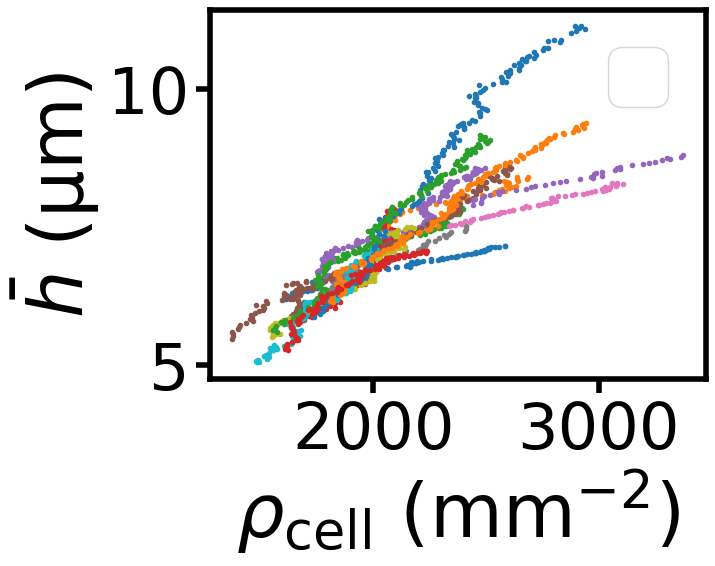

In [16]:
measure     = "pixel"   # define measure (pixel or disc)
density_bin = 200       # size of density bin (1/mm^2)


datasets = [
            "MDCK_20240301_B1-4", 
            "MDCK_20240301_B2-2",
            "MDCK_20240301_B2-6",
            "MDCK_20240317_B1-1",
            "MDCK_20240319_A1-9",
            "MDCK_20240319_A1-13",
            "MDCK_20240319_A1-16",
            "MDCK_20240319_A1-18",
            "MDCK_20240319_B1-11",
            "MDCK_20240516_A2-1",
            "MDCK_20240516_A2-7",
            "MDCK_20240516_B1-9",
            "MDCK_20240516_B1-13",
            "MDCK_20240516_B1-22",
            "MDCK_20250210_A2-1",
            "MDCK_20250904_B1-1"
            ]


# Load height averages, std, and corersponding cell density
h_means = []
h_stds  = []
densities = []

for dataset in datasets:
    cells = SegmentedCells(f"{data_path}cell_features/calibrated/{dataset}_cells.p")

    h_means.append(np.load(f"data/mean_evolutions/{dataset}_h_{measure}_mean.npy"))
    h_stds. append(np.load(f"data/mean_evolutions/{dataset}_h_{measure}_std.npy") )
    densities.append(cells.density)


# Plot averages of every dataset
for rho, h, dataset in zip(densities, h_means, datasets):
    plt.plot(rho, h, '.')

plt.xlabel(r"$\rho_{\text{cell}}$ (mm$^{-2}$)")
plt.ylabel(r"$\bar{h}$ (µm)")
plt.legend();

## Bin data by density, and take average over technical and biological replicates

In [17]:
# Define dishes to take technical averages over
dishes = ["MDCK_20240301_B1",
          "MDCK_20240301_B2", 
          "MDCK_20240317_B1", 
          "MDCK_20240319_A1",
          "MDCK_20240319_B1",
          "MDCK_20240516_A2",
          "MDCK_20240516_B1",
          "MDCK_20250210_A2", 
          "MDCK_20250904_B1"
          ]

# Define microscopes to take biological replicates over
microscopes = ["holomonitor", "tomocube"]

# Define range of cell densities to bin data by
min_density = 100 * int(min(np.concatenate(densities)) / 100)
max_density = 100 * int(max(np.concatenate(densities)) / 100)
binned_densities = np.arange(min_density, max_density + density_bin, density_bin)

### Technical replicates

/home/silja/Documents/MDCK-QPI/venv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:982: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/tmp/ipykernel_1248449/683138040.py:51: OptimizeWarning: Covariance of the parameters could not be estimated
  param, cov = curve_fit(poly2, all_binned_densities, dish_mean.compressed(), p0=[0, 4/1500, 2], sigma=dish_std.compressed())


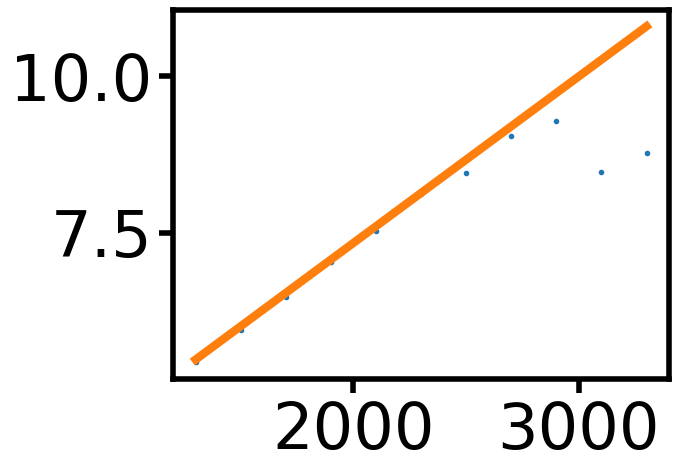

In [18]:
# Bin data while taking unweighted average of technical replicates. Could also be done in two separate steps?

dish_mean = []
dish_std  = []

# Loop over unique petri dishes
for dish in dishes:
    mean_arr = []
    std_arr  = []
    density_arr = []

    # Loop through techincal replicates in dish
    for dataset, mean, std, rho in zip(datasets, h_means, h_stds, densities):

        # add data to temporary array to be fed to bin_data_by_density
        if dish in dataset:
            mean_arr.append(mean)
            std_arr.append(std)
            density_arr.append(rho)

    # adapt input to function
    mean_arr    = np.concatenate(mean_arr)
    std_arr     = np.concatenate(std_arr) 
    density_arr = np.concatenate(density_arr)

    # bin data
    hmean_tmp, hstd_tmp, counts = bin_data_by_density(mean_arr,
                                                      std_arr, 
                                                      density_arr, 
                                                      bin_range=[min_density, max_density], 
                                                      bin_size=density_bin,
                                                      weighted=False)

    dish_mean.append(hmean_tmp)
    dish_std.append(hstd_tmp)


dish_mean = np.ma.array(dish_mean, mask=np.array(dish_mean) == 0)
dish_std  = np.ma.array(dish_std,  mask=np.array(dish_mean) == 0)


# for mean, std, dish in zip(dish_mean, dish_std, dishes):
#     plt.plot(binned_densities, mean, '.', label=dish.split("_")[1:3])
#     #plt.errorbar(binned_densities, mean, yerr=std, fmt='.', label=dish.split("_")[1:3])

def poly2(x, a, b, c):
    return a*x**2 + b*x + c

from scipy.optimize import curve_fit
all_binned_densities = np.concatenate([binned_densities[mask] for mask in ~dish_mean.mask])
param, cov = curve_fit(poly2, all_binned_densities, dish_mean.compressed(), p0=[0, 4/1500, 2], sigma=dish_std.compressed())

plt.plot(binned_densities, np.ma.mean(dish_mean, axis=0), '.')
plt.plot(binned_densities, poly2(binned_densities, *param))

## Take final average over microscopes and plot

/tmp/ipykernel_1248449/3964617181.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


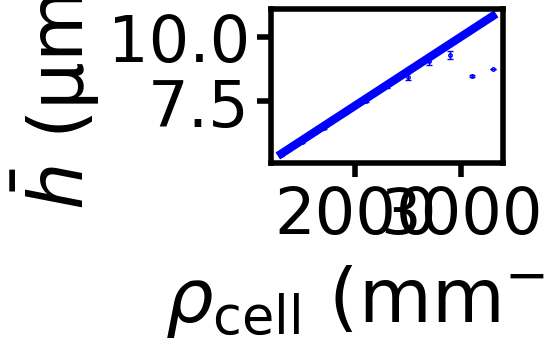

In [19]:
hmean = np.ma.mean(dish_mean, axis=0)
herr  = np.ma.std(dish_mean, axis=0) / np.sqrt(np.sum(~dish_std.mask))

# Plot
fig = plt.figure(figsize=(3,2))

plt.errorbar(binned_densities, 
             hmean, 
             herr, 
             color="b", fmt=".", ms=5,
             lw=1, capsize=2, capthick=1, fillstyle="none")


# fit = linregress(binned_densities, hmean)
plt.plot(binned_densities, poly2(binned_densities, *param), '-b')
# plt.plot(binned_densities[:-1], 
#          fit.intercept + fit.slope * binned_densities[:-1],
#          "-", c="gray", lw=2)

plt.xlabel(r"$\rho_{\text{cell}}$ (mm$^{-2}$)")
plt.ylabel(r"$\bar{h}$ (µm)")

fig.tight_layout()
# fig.savefig(f"figs/paper/{measure}wise_height.svg")

In [20]:
# Linear regression
def linear(x, a, b):
    return a*x + b

Vmean = 10**6 * hmean / binned_densities
Verr  = 10**6 * herr / binned_densities

# hfit = linregress(binned_densities, hmean)
#Vfit = linregress(binned_densities, Vmean)

#hparam, cov = curve_fit(poly2, all_binned_densities, dish_mean.compressed(), p0=[0, 4/1500, 2])#, sigma=dish_std.compressed())

hparam, hpopt = curve_fit(poly2, binned_densities[:-2], hmean[:-2], p0=[0, 4/1500, 2], sigma=herr[:-2])
Vparam, Vpopt = curve_fit(poly2, binned_densities[:-2], Vmean[:-2], p0=[0, -0.1, 4500], sigma=Verr[:-2])

hfit = poly2(binned_densities, *hparam) #[0] * binned_densities + hparam[1]
Vfit = poly2(binned_densities, *Vparam) #[0] * binned_densities + hparam[1]Vparam[0] * binned_densities + Vparam[1]

print(f"h = ({hparam[0]:0.9f} +/- {hpopt[0,0]:0.9f}) rho + ({hparam[1]:0.2f} +/- {hpopt[1,1]:0.2f})µm")
print(f"V = ({Vparam[0]:0.4f} +/- {Vpopt[0,0]:0.4f}) rho + ({Vparam[1]:0.0f} +/- {Vpopt[1,1]:0.0f})µm³")

print(f"{Vparam[0]:0.5f} +/- {Vpopt[0,0]:0.5f}")
Vparam

h = (-0.000000204 +/- 0.000000000) rho + (0.00 +/- 0.00)µm
V = (0.0002 +/- 0.0000) rho + (-1 +/- 0)µm³
0.00017 +/- 0.00000


array([ 1.67750694e-04, -1.24992232e+00,  5.46534373e+03])

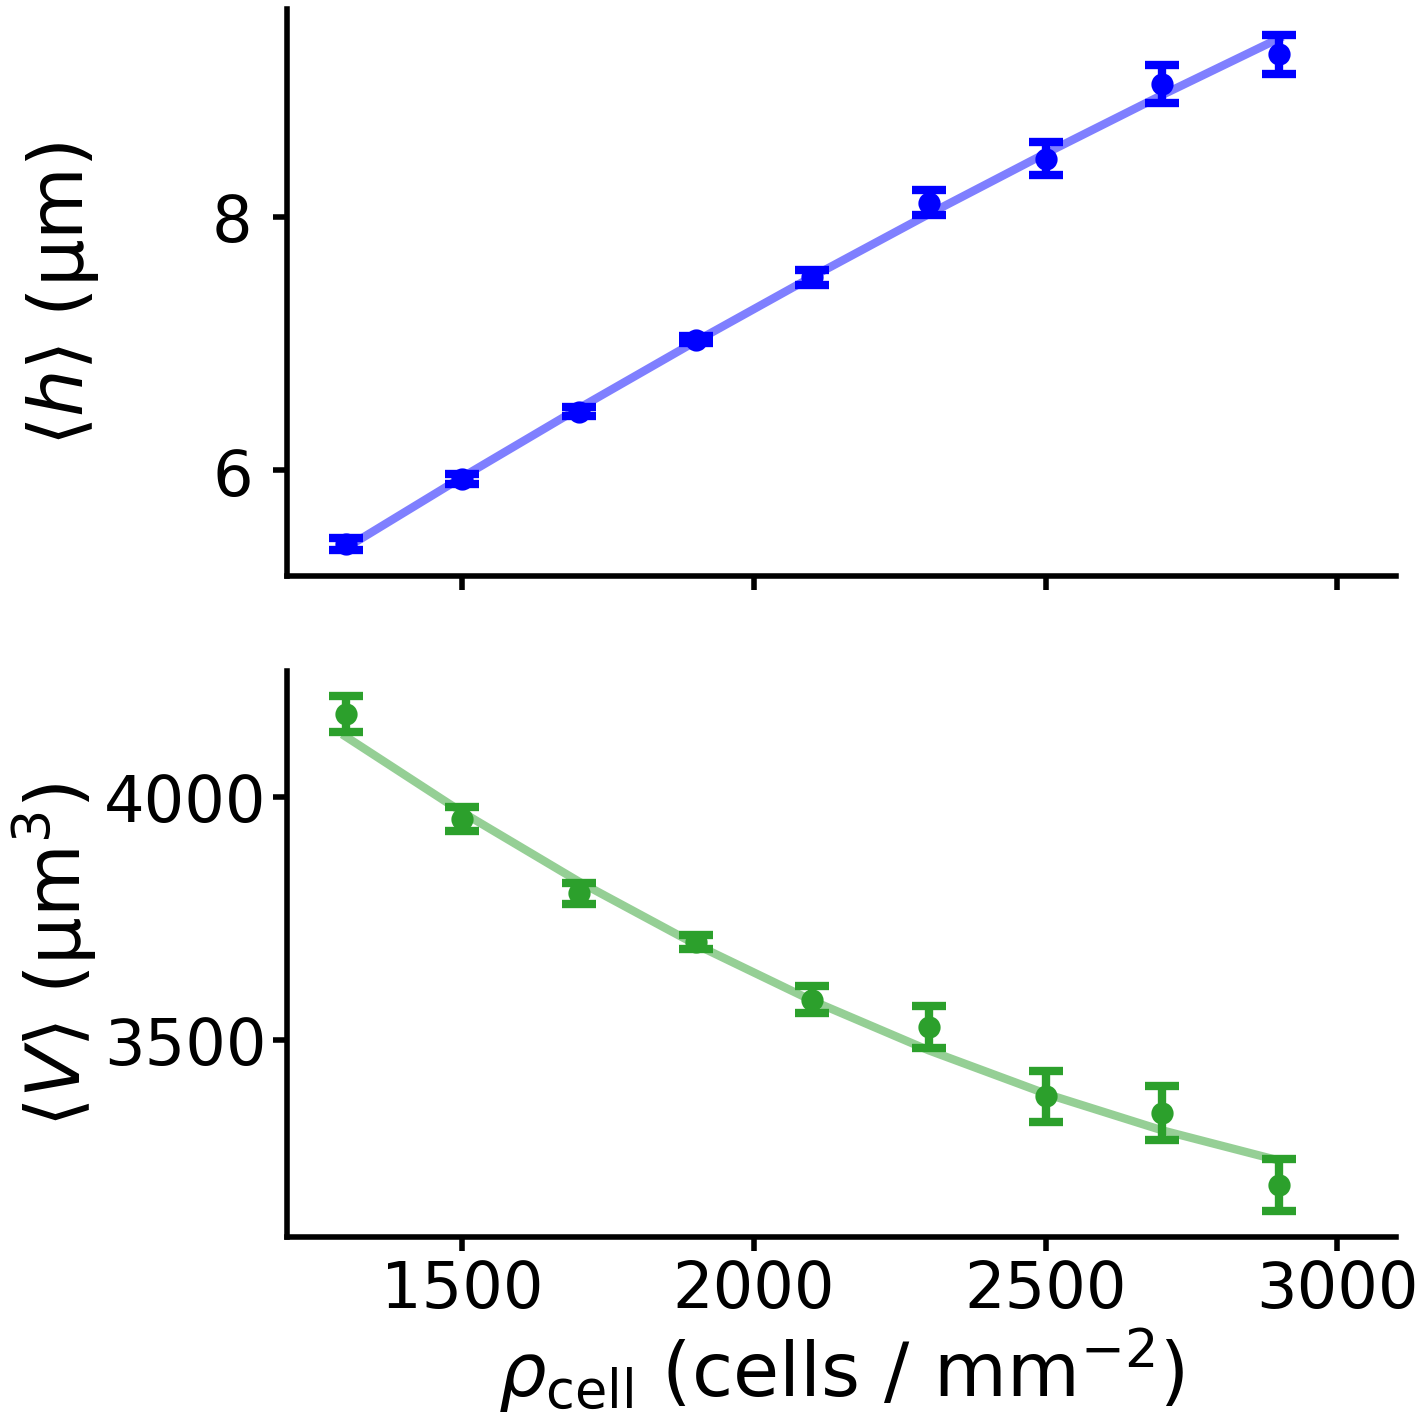

In [21]:

mm = 0.1 / 2.54  # centimeters in inches
font  = {'size' : 54}
lines = {'lw': 6}
axes  = {'lw': 4}
xticks = {'width': 4}
mpl.rc('font',  **font)
mpl.rc('lines', **lines)
mpl.rc('axes',  **axes)

# before the call to subplot
plt.rc('font', weight ='normal')
plt.rc('xtick.major', size = 10, pad = 5, width=4)
plt.rc('ytick.major', size = 10, pad = 5, width=4)
plt.rc('xtick', labelsize = 46)
plt.rc('ytick', labelsize = 46)

# Plot
fig, ax = plt.subplots(2,1, figsize=(398*mm, 398*mm), sharex=True)
ax[0].tick_params(axis='y', which='major', pad=15)
fig.subplots_adjust(left   = 8.5/35,
                    right  = 0.995,
                    top    = 0.995,
                    bottom = 5/34,
                    hspace = 2/13)



ax[0].plot(binned_densities[:-2], 
         hfit[:-2],
         "-", c="b", alpha=0.5)

ax[1].plot(binned_densities[:-2], 
           Vfit[:-2],
        "-", c="tab:green", alpha=0.5)

ax[0].errorbar(binned_densities[:-2], 
             hmean[:-2], 
             herr[:-2], 
             color="b", fmt=".", ms=20, fillstyle="full", markeredgewidth=6,
             capsize=12, capthick=6)

ax[1].errorbar(binned_densities[:-2], 
             Vmean[:-2], 
             Verr[:-2], 
             color="tab:green", fmt=".", ms=20, fillstyle="full", markeredgewidth=6,
             capsize=12, capthick=6)

ax[0].set_ylabel(ylabel=r"$\langle h \rangle$ (µm)", labelpad=80)
ax[0].set(xlim=(1200, 3100))
ax[1].set(ylabel=r"$\langle V \rangle$ (µm$^{3}$)",
          xlabel=r"$\rho_{\text{cell}}$ (cells$~/~$mm$^{-2}$)")#,
        #   ylim=(1450, 2800))


for axi in ax:
    axi.spines['right'].set_visible(False)
    axi.spines['top'].set_visible(False)

fig.tight_layout()#
fig.savefig(f"figs/Elife/subfigures/{measure}wise_height_volume.svg")